  TERZINA Binary Parser
File: data_06_11-22_15.bin
Size: 634.0 MB
Parsing...............................
Done! Parsed 312351 packets.
  DAQ1: 233751 events
  DAQ2: 233330 events
  DAQ3: 221102 events
  DAQ4: 238467 events

  TERZINA Finger Plot — Interactive Mode
Available DAQs and event counts:
  [✓] DAQ1: 233751 events
  [✓] DAQ2: 233330 events
  [✓] DAQ3: 221102 events
  [✓] DAQ4: 238467 events

----------------------------------------


Enter DAQ ASIC CH [GAIN] (e.g. '1 A 30' or '3 C 21 LG')
  or 'all' for full 640-channel overview
  or 'gain' for gain distribution (Plot 3)
  or 'pedestal' for pedestal map (Plot 4)
  or 'resolution' for energy resolution (Plot 5)
  or 'pvr' for peak-to-valley ratio (Plot 6)
  or 'hglg' for HG vs LG correlation (Plot 10)
  or 'hglg DAQ ASIC CH' for single channel
  or 'q' to quit:  4 A 6


  Plotting DAQ4 ASIC-A CH6 HG...
Saved: finger_DAQ4_ASICA_CH6_HG.png
  → 10 peaks found, Gain = 424.32 ADC/p.e.


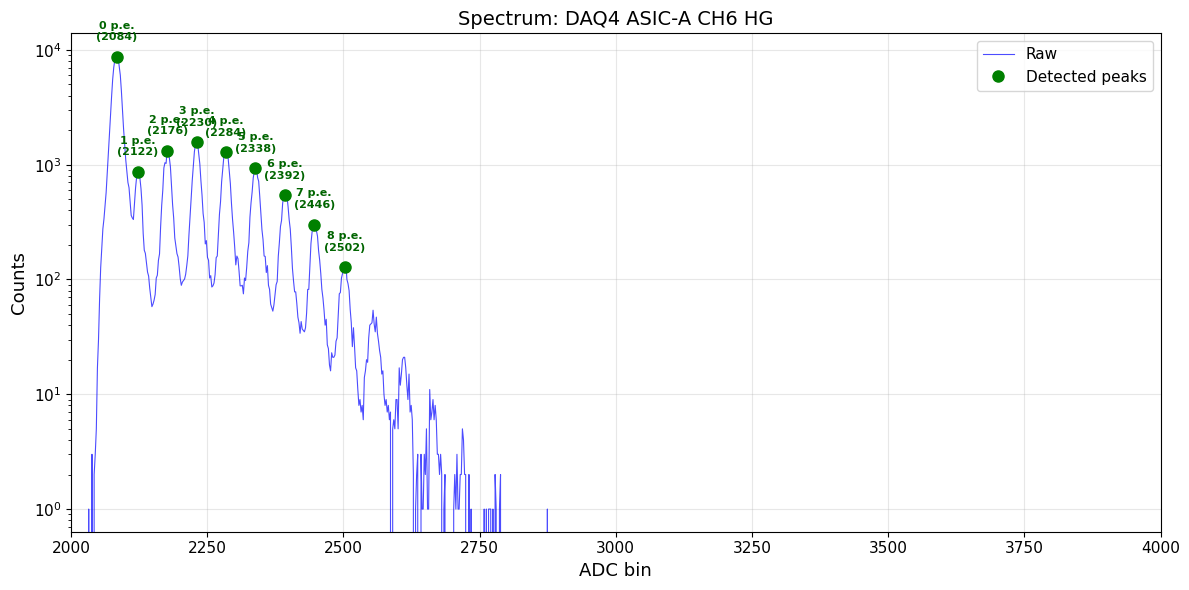

In [ ]:
## """TERZINA FPA — Binary Data Parser & Finger Plot Analysis
#=========================================================
#Parses .bin files from the TERZINA FPA (4 DAQs × 5 ASICs × 32 channels),
#extracts HG/LG/HIT data, builds charge spectra histograms, and generates
#finger plots with peak detection and gain estimation.

#Usage:
#    python terzina_finger_plot.py

#Configure BIN_FILE path below, then select DAQ/ASIC/CH interactively.
#"""

import os
import sys
import struct
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter1d
from scipy.signal import find_peaks
from scipy.optimize import curve_fit
from dataclasses import dataclass, field

# =============================================================================
# CONFIGURATION — Edit these before running
# =============================================================================
BIN_FILE = r"data_06_11-22_15.bin"      #"data_06_11-22_15.bin"
MAX_PACKETS = None        # None = parse all packets, or set e.g. 50000
NBINS = 16384             # ADC histogram bins (14-bit)
REBIN_FACTOR = 2          # Rebin factor: 1=no rebin, 2=8192 bins, 4=4096, 8=2048
SMOOTH_SIGMA = 2.0        # Gaussian smoothing sigma for peak finding
PEAK_PROMINENCE = 0.005   # Peak prominence as fraction of max
PEAK_DISTANCE = 10        # Minimum distance between peaks (in rebinned bins)
GAUSS_FIT_WINDOW = 6      # Half-window for Gaussian fitting around peaks


# =============================================================================
# TERZINApack dataclass
# =============================================================================
@dataclass
class TERZINApack:
    TIMESTAMP: int = 0
    ID_CONC: int = 0

    DAQ1_ID: int = 0
    DAQ1TRIG_counter: int = 0
    DAQ1_data1: int = 0
    DAQ1_data2: int = 0
    D1_A: list = field(default_factory=list)
    D1_B: list = field(default_factory=list)
    D1_C: list = field(default_factory=list)
    D1_D: list = field(default_factory=list)
    D1_E: list = field(default_factory=list)
    D1_LOST: int = 0
    D1_REAL: int = 0

    DAQ2_ID: int = 0
    DAQ2TRIG_counter: int = 0
    DAQ2_data1: int = 0
    DAQ2_data2: int = 0
    D2_A: list = field(default_factory=list)
    D2_B: list = field(default_factory=list)
    D2_C: list = field(default_factory=list)
    D2_D: list = field(default_factory=list)
    D2_E: list = field(default_factory=list)
    D2_LOST: int = 0
    D2_REAL: int = 0

    DAQ3_ID: int = 0
    DAQ3TRIG_counter: int = 0
    DAQ3_data1: int = 0
    DAQ3_data2: int = 0
    D3_A: list = field(default_factory=list)
    D3_B: list = field(default_factory=list)
    D3_C: list = field(default_factory=list)
    D3_D: list = field(default_factory=list)
    D3_E: list = field(default_factory=list)
    D3_LOST: int = 0
    D3_REAL: int = 0

    DAQ4_ID: int = 0
    DAQ4TRIG_counter: int = 0
    DAQ4_data1: int = 0
    DAQ4_data2: int = 0
    D4_A: list = field(default_factory=list)
    D4_B: list = field(default_factory=list)
    D4_C: list = field(default_factory=list)
    D4_D: list = field(default_factory=list)
    D4_E: list = field(default_factory=list)
    D4_LOST: int = 0
    D4_REAL: int = 0


# =============================================================================
# Binary Parser
# =============================================================================
class TERZINAParser:
    """Parses TERZINA binary data files and stores per-channel HG/LG/HIT."""

    DAQ_IDS = {
        0x00AAAA00: 1,
        0x00BBBB00: 2,
        0x00CCCC00: 3,
        0x00DDDD00: 4,
    }
    CONC_HEADER = 0xCA00FE11DD651983
    VALID_PACK_ID = 0xA77A

    def __init__(self, file_path):
        if not os.path.exists(file_path):
            raise FileNotFoundError(f"Binary file not found: {file_path}")

        self.file_path = file_path
        self.file_size = os.path.getsize(file_path)

        # Storage: flat lists per ASIC, interleaved 32 channels per event
        self.channels = {}
        for daq in range(1, 5):
            for asic in "ABCDE":
                self.channels[f"D{daq}_{asic}_HG"] = []
                self.channels[f"D{daq}_{asic}_LG"] = []
                self.channels[f"D{daq}_{asic}_HIT"] = []

        self.n_packets = 0
        self.events_per_daq = {1: 0, 2: 0, 3: 0, 4: 0}

    @staticmethod
    def _extract_hg_lg_hit(word_list):
        """Unpack 32-bit words into HG (0-13), LG (14-27), HIT (28-31)."""
        HG, LG, HIT = [], [], []
        for w in word_list:
            HG.append(w & 0x3FFF)
            LG.append((w >> 14) & 0x3FFF)
            HIT.append((w >> 28) & 0xF)
        return HG, LG, HIT

    def _parse_payload(self, payload):
        """Parse a single TERZINA payload into a TERZINApack."""
        pack = TERZINApack()
        offset = 0

        def u32():
            nonlocal offset
            v = int.from_bytes(payload[offset:offset + 4], "little")
            offset += 4
            return v

        def u64():
            nonlocal offset
            v = int.from_bytes(payload[offset:offset + 8], "little")
            offset += 8
            return v

        pack.TIMESTAMP = u64()
        pack.ID_CONC = u64()

        if pack.ID_CONC != self.CONC_HEADER:
            return pack

        daq_id = u32()
        id_prog = 0

        while True:
            if offset >= len(payload) - 4:
                break

            if daq_id == 0x00AAAA00:
                pack.DAQ1_ID = daq_id
                pack.DAQ1TRIG_counter = u32()
                pack.DAQ1_data1 = u32()
                pack.DAQ1_data2 = u32()
                pack.D1_A = [0x3FFF - u32() for _ in range(32)]
                pack.D1_B = [0x3FFF - u32() for _ in range(32)]
                pack.D1_C = [0x3FFF - u32() for _ in range(32)]
                pack.D1_D = [0x3FFF - u32() for _ in range(32)]
                pack.D1_E = [0x3FFF - u32() for _ in range(32)]
                pack.D1_LOST = u64()
                pack.D1_REAL = u64()
                daq_id = u32()
                id_prog += 1

            elif daq_id == 0x00BBBB00:
                pack.DAQ2_ID = daq_id
                pack.DAQ2TRIG_counter = u32()
                pack.DAQ2_data1 = u32()
                pack.DAQ2_data2 = u32()
                pack.D2_A = [0x3FFF - u32() for _ in range(32)]
                pack.D2_B = [0x3FFF - u32() for _ in range(32)]
                pack.D2_C = [0x3FFF - u32() for _ in range(32)]
                pack.D2_D = [0x3FFF - u32() for _ in range(32)]
                pack.D2_E = [0x3FFF - u32() for _ in range(32)]
                pack.D2_LOST = u64()
                pack.D2_REAL = u64()
                daq_id = u32()
                id_prog += 1

            elif daq_id == 0x00CCCC00:
                pack.DAQ3_ID = daq_id
                pack.DAQ3TRIG_counter = u32()
                pack.DAQ3_data1 = u32()
                pack.DAQ3_data2 = u32()
                pack.D3_A = [0x3FFF - u32() for _ in range(32)]
                pack.D3_B = [0x3FFF - u32() for _ in range(32)]
                pack.D3_C = [0x3FFF - u32() for _ in range(32)]
                pack.D3_D = [0x3FFF - u32() for _ in range(32)]
                pack.D3_E = [0x3FFF - u32() for _ in range(32)]
                pack.D3_LOST = u64()
                pack.D3_REAL = u64()
                daq_id = u32()
                id_prog += 1

            elif daq_id == 0x00DDDD00:
                pack.DAQ4_ID = daq_id
                pack.DAQ4TRIG_counter = u32()
                pack.DAQ4_data1 = u32()
                pack.DAQ4_data2 = u32()
                pack.D4_A = [0x3FFF - u32() for _ in range(32)]
                pack.D4_B = [0x3FFF - u32() for _ in range(32)]
                pack.D4_C = [0x3FFF - u32() for _ in range(32)]
                pack.D4_D = [0x3FFF - u32() for _ in range(32)]
                pack.D4_E = [0x3FFF - u32() for _ in range(32)]
                pack.D4_LOST = u64()
                pack.D4_REAL = u64()
                break

            elif daq_id == 0xDEADBEEF:
                if id_prog == 3:
                    try:
                        daq_id = u32()
                    except:
                        pass
                    break
                id_prog += 1
                daq_id = u32()
                daq_id = u32()

            else:
                id_prog += 1
                offset += 796
                if offset >= len(payload):
                    break
                daq_id = u32()

        return pack

    def _store_pack(self, pack):
        """Extract HG/LG/HIT from pack and append to channel storage."""
        asic_map = {
            1: [("A", pack.D1_A), ("B", pack.D1_B), ("C", pack.D1_C),
                ("D", pack.D1_D), ("E", pack.D1_E)],
            2: [("A", pack.D2_A), ("B", pack.D2_B), ("C", pack.D2_C),
                ("D", pack.D2_D), ("E", pack.D2_E)],
            3: [("A", pack.D3_A), ("B", pack.D3_B), ("C", pack.D3_C),
                ("D", pack.D3_D), ("E", pack.D3_E)],
            4: [("A", pack.D4_A), ("B", pack.D4_B), ("C", pack.D4_C),
                ("D", pack.D4_D), ("E", pack.D4_E)],
        }

        for daq_num, asic_list in asic_map.items():
            for asic_name, data in asic_list:
                if len(data) == 0:
                    continue
                HG, LG, HIT = self._extract_hg_lg_hit(data)
                prefix = f"D{daq_num}_{asic_name}"
                self.channels[f"{prefix}_HG"].extend(HG)
                self.channels[f"{prefix}_LG"].extend(LG)
                self.channels[f"{prefix}_HIT"].extend(HIT)
            # Count events for this DAQ
            if len(asic_list[0][1]) > 0:
                self.events_per_daq[daq_num] += 1

    def parse(self, max_packets=None):
        """Parse the entire binary file."""
        print(f"File: {self.file_path}")
        print(f"Size: {self.file_size / 1e6:.1f} MB")
        print("Parsing", end="", flush=True)

        with open(self.file_path, "rb") as f:
            while True:
                header = f.read(12)
                if len(header) < 12:
                    break

                id_pack = struct.unpack("<I", header[0:4])[0]
                len_pack = struct.unpack("<I", header[4:8])[0]
                # pack_counter = struct.unpack("<I", header[8:12])[0]

                if id_pack == self.VALID_PACK_ID:
                    payload = f.read(len_pack)
                    if len(payload) < len_pack:
                        break
                    pack = self._parse_payload(payload)
                    self._store_pack(pack)
                    self.n_packets += 1

                    # Progress indicator
                    if self.n_packets % 10000 == 0:
                        print(".", end="", flush=True)

                    if max_packets and self.n_packets >= max_packets:
                        break
                else:
                    # Skip unknown packet
                    try:
                        f.read(len_pack)
                    except:
                        break

        print(f"\nDone! Parsed {self.n_packets} packets.")
        for d in range(1, 5):
            print(f"  DAQ{d}: {self.events_per_daq[d]} events")

        return self

    def get_channel_values(self, daq, asic, ch, gain="HG"):
        """Extract per-event values for a specific channel."""
        key = f"D{daq}_{asic.upper()}_{gain.upper()}"
        all_vals = self.channels[key]
        if len(all_vals) == 0:
            return np.array([])
        return np.array(all_vals[ch::32])

    def get_histogram(self, daq, asic, ch, gain="HG", nbins=NBINS, rebin=REBIN_FACTOR):
        """Build a histogram for a specific channel with optional rebinning."""
        vals = self.get_channel_values(daq, asic, ch, gain)
        if len(vals) == 0:
            n_out = nbins // rebin
            return np.zeros(n_out), np.arange(n_out) * rebin + rebin / 2

        hist, edges = np.histogram(vals, bins=nbins, range=(0, nbins))

        # Rebin: sum groups of 'rebin' adjacent bins
        if rebin > 1:
            n_out = nbins // rebin
            hist = hist[:n_out * rebin].reshape(n_out, rebin).sum(axis=1)
            bin_centers = edges[:n_out * rebin].reshape(n_out, rebin).mean(axis=1)
        else:
            bin_centers = (edges[:-1] + edges[1:]) / 2

        return hist, bin_centers


# =============================================================================
# Gaussian fitting
# =============================================================================
def gaussian(x, A, mu, sigma):
    return A * np.exp(-(x - mu) ** 2 / (2 * sigma ** 2))


def fit_peak_gaussian(x, y, peak_idx, window=GAUSS_FIT_WINDOW):
    """Fit a Gaussian to a single peak and return (mu, sigma, amplitude)."""
    lo = max(0, peak_idx - window)
    hi = min(len(x), peak_idx + window + 1)
    xw = x[lo:hi]
    yw = y[lo:hi]

    try:
        A0 = yw.max()
        mu0 = x[peak_idx]
        sigma0 = (xw[-1] - xw[0]) / 4
        popt, _ = curve_fit(gaussian, xw, yw, p0=[A0, mu0, sigma0],
                            maxfev=5000)
        return popt[1], abs(popt[2]), popt[0]  # mu, sigma, A
    except Exception:
        return float(x[peak_idx]), 1.0, float(y[peak_idx])


# =============================================================================
# Finger Plot
# =============================================================================
def finger_plot(parser, daq, asic, ch, gain="HG",
                sigma=SMOOTH_SIGMA, save_path=None):
    """
    Generate a finger plot for a specific DAQ/ASIC/CH.
    Returns (fig, peaks, gain_value).
    """
    hist, bins = parser.get_histogram(daq, asic, ch, gain)
    n_events = parser.events_per_daq[daq]
    ch_vals = parser.get_channel_values(daq, asic, ch, gain)

    if len(ch_vals) == 0 or hist.max() == 0:
        print(f"No data for DAQ{daq} ASIC-{asic} CH{ch} {gain}")
        return None, np.array([]), None

    # Smooth for peak finding
    ys = gaussian_filter1d(hist.astype(float), sigma=sigma)

    # Find peaks
    peaks, props = find_peaks(
        ys,
        prominence=PEAK_PROMINENCE * ys.max(),
        distance=PEAK_DISTANCE
    )
    peaks = np.sort(peaks)

    # Gaussian fit each peak
    fitted_positions = []
    fitted_sigmas = []
    for p in peaks:
        mu, sig, _ = fit_peak_gaussian(bins, ys, p)
        fitted_positions.append(mu)
        fitted_sigmas.append(sig)
    fitted_positions = np.array(fitted_positions)
    fitted_sigmas = np.array(fitted_sigmas)

    # Gain calculation
    gain_val = None
    if len(fitted_positions) > 1:
        spacings = np.diff(fitted_positions)
        gain_val = np.mean(spacings)

    # ---- PLOT ----
    fig, ax = plt.subplots(figsize=(12, 6))

    # Raw histogram
    ax.plot(bins, hist, "b-", lw=0.8, alpha=0.7, label="Raw")

    # Detected peaks
    if len(peaks) > 0:
        ax.plot(bins[peaks], hist[peaks], "go", markersize=8,
                label="Detected peaks")

        # Annotate p.e. numbers
        for i, p in enumerate(peaks):
            ax.annotate(
                f"{i} p.e.\n({bins[p]:.0f})",
                xy=(bins[p], hist[p]),
                xytext=(0, 12),
                textcoords="offset points",
                ha="center", fontsize=8, color="darkgreen",
                fontweight="bold",
            )

    # Zoom to region of interest
    nonzero = np.where(hist > 0)[0]
    if len(nonzero) > 0:
        ax.set_xlim(bins[nonzero.min()] - 50, bins[nonzero.max()] + 50)

    ax.set_xlabel("ADC bin", fontsize=13)
    ax.set_ylabel("Counts", fontsize=13)
    ax.set_yscale("log")
    ax.tick_params(labelsize=11)
    ax.set_title(
        f"Spectrum: DAQ{daq} ASIC-{asic} CH{ch} {gain}",
        fontsize=14,
    )
    ax.legend(fontsize=11, loc="upper right")
    ax.grid(True, alpha=0.3)
                      
    
    ax.set_xlim(2000, 4000)    

    plt.tight_layout()

    if save_path:
        fig.savefig(save_path, dpi=150, bbox_inches="tight")
        print(f"Saved: {save_path}")

    return fig, fitted_positions, gain_val


# =============================================================================
# Full FPA Overview — All 640 channels
# =============================================================================
def plot_all_channels(parser, gain="HG", save_path=None):
    """
    Plot all 640 channels (4 DAQs × 5 ASICs × 32 CH) as a 2D color map.
    X-axis = ADC bin, Y-axis = channel index (0–639).
    Dead SiPMs/ASICs will appear as blank horizontal bands.
    """
    asics = ["A", "B", "C", "D", "E"]
    daqs = [1, 2, 3, 4]
    n_channels = len(daqs) * len(asics) * 32  # 640

    # Build 2D array: rows=channels, cols=ADC bins (rebinned)
    sample_hist, sample_bins = parser.get_histogram(1, "A", 0, gain)
    n_adc = len(sample_hist)

    spectra = np.zeros((n_channels, n_adc))
    labels = []
    ch_idx = 0

    for daq in daqs:
        for asic in asics:
            for ch in range(32):
                hist, bins = parser.get_histogram(daq, asic, ch, gain)
                spectra[ch_idx, :] = hist
                labels.append(f"D{daq}_{asic}_CH{ch}")
                ch_idx += 1

    # Find global ADC range with data
    col_sums = spectra.sum(axis=0)
    nonzero_cols = np.where(col_sums > 0)[0]
    if len(nonzero_cols) == 0:
        print("No data found in any channel.")
        return None

    adc_lo = max(0, nonzero_cols.min() - 20)
    adc_hi = min(n_adc - 1, nonzero_cols.max() + 20)

    # Crop to region of interest
    spectra_crop = spectra[:, adc_lo:adc_hi + 1]
    bins_crop = bins[adc_lo:adc_hi + 1]

    # Log scale for better visibility
    spectra_log = np.log10(spectra_crop + 1)  # +1 to avoid log(0)

    # ---- PLOT ----
    fig, ax = plt.subplots(figsize=(16, 12))

    im = ax.imshow(
        spectra_log,
        aspect="auto",
        origin="lower",
        extent=[bins_crop[0], bins_crop[-1], 0, n_channels],
        cmap="viridis",
        interpolation="nearest",
    )

    cbar = fig.colorbar(im, ax=ax, label="log₁₀(Counts + 1)", shrink=0.8)

    # DAQ/ASIC boundary lines and labels
    for daq_i, daq in enumerate(daqs):
        daq_start = daq_i * 160
        # DAQ boundary
        ax.axhline(y=daq_start, color="red", lw=1.5, alpha=0.8)
        ax.text(
            bins_crop[0] - (bins_crop[-1] - bins_crop[0]) * 0.01,
            daq_start + 80,
            f"DAQ{daq}",
            fontsize=11, fontweight="bold", color="red",
            ha="right", va="center",
        )
        # ASIC boundaries within each DAQ
        for asic_i, asic in enumerate(asics):
            asic_start = daq_start + asic_i * 32
            if asic_i > 0:
                ax.axhline(y=asic_start, color="white", lw=0.5, alpha=0.5, linestyle="--")

    # Top boundary
    ax.axhline(y=n_channels, color="red", lw=1.5, alpha=0.8)

    ax.set_xlabel("ADC bin", fontsize=13)
    ax.set_ylabel("Channel index", fontsize=13)
    ax.set_title(
        f"TERZINA FPA — All {n_channels} Channels ({gain})",
        fontsize=15,
    )
    ax.tick_params(labelsize=11)

    # Secondary y-axis ticks at ASIC boundaries
    asic_ticks = []
    asic_labels_list = []
    for daq_i, daq in enumerate(daqs):
        for asic_i, asic in enumerate(asics):
            pos = daq_i * 160 + asic_i * 32 + 16
            asic_ticks.append(pos)
            asic_labels_list.append(f"D{daq}-{asic}")

    ax2 = ax.secondary_yaxis("right")
    ax2.set_yticks(asic_ticks)
    ax2.set_yticklabels(asic_labels_list, fontsize=7)

    plt.tight_layout()

    if save_path:
        fig.savefig(save_path, dpi=150, bbox_inches="tight")
        print(f"Saved: {save_path}")

    # ---- Per-channel statistics summary ----
    print(f"\n{'='*60}")
    print(f"  CHANNEL STATISTICS ({gain})")
    print(f"{'='*60}")

    dead_channels = []
    for i, label in enumerate(labels):
        total = spectra[i].sum()
        if total == 0:
            dead_channels.append(label)

    if dead_channels:
        print(f"\n  Dead/empty channels ({len(dead_channels)}):")
        # Group by ASIC
        from collections import defaultdict
        dead_by_asic = defaultdict(list)
        for dc in dead_channels:
            asic_key = dc.rsplit("_CH", 1)[0]
            ch_num = int(dc.rsplit("CH", 1)[1])
            dead_by_asic[asic_key].append(ch_num)

        for asic_key in sorted(dead_by_asic.keys()):
            chs = dead_by_asic[asic_key]
            if len(chs) == 32:
                print(f"    {asic_key}: ALL 32 channels dead ← entire ASIC/SiPM dead")
            else:
                print(f"    {asic_key}: CH {chs}")
    else:
        print("  All channels have data.")

    return fig


# =============================================================================
# Plot 3: Gain Distribution Histogram
# =============================================================================
def plot_gain_distribution(parser, gain="HG", save_path=None):
    """
    Compute gain (ADC/p.e.) for all 640 channels and plot the distribution.
    Returns a dict of {(daq, asic, ch): gain_value} and the figure.
    """
    asics = ["A", "B", "C", "D", "E"]
    daqs = [1, 2, 3, 4]

    gain_values = {}
    failed_channels = []

    print("Computing gain for all channels...")
    for daq in daqs:
        if parser.events_per_daq[daq] == 0:
            continue
        for asic in asics:
            for ch in range(32):
                hist, bins = parser.get_histogram(daq, asic, ch, gain)
                if hist.max() == 0:
                    failed_channels.append((daq, asic, ch, "no data"))
                    continue

                # Smooth and find peaks
                ys = gaussian_filter1d(hist.astype(float), sigma=SMOOTH_SIGMA)
                peaks, _ = find_peaks(
                    ys,
                    prominence=PEAK_PROMINENCE * ys.max(),
                    distance=PEAK_DISTANCE,
                )

                if len(peaks) < 3:
                    failed_channels.append((daq, asic, ch, f"{len(peaks)} peaks"))
                    continue

                # Gaussian fit each peak for precise positions
                positions = []
                for p in peaks:
                    mu, sig, _ = fit_peak_gaussian(bins, ys, p)
                    positions.append(mu)
                positions = np.array(positions)

                # Gain = mean spacing between consecutive peaks
                spacings = np.diff(positions)
                # Filter out outlier spacings (> 2x or < 0.5x the median)
                median_sp = np.median(spacings)
                good = (spacings > 0.5 * median_sp) & (spacings < 2.0 * median_sp)
                if good.sum() == 0:
                    failed_channels.append((daq, asic, ch, "bad spacings"))
                    continue

                g = np.mean(spacings[good])
                gain_values[(daq, asic, ch)] = g

    n_good = len(gain_values)
    n_fail = len(failed_channels)
    print(f"  Gain extracted (raw): {n_good} channels")
    print(f"  Failed: {n_fail} channels")

    if n_good == 0:
        print("  No channels with valid gain — cannot plot distribution.")
        return {}, None

    # ---- Outlier rejection using IQR ----
    all_gains_raw = np.array(list(gain_values.values()))
    q1, q3 = np.percentile(all_gains_raw, [25, 75])
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr

    # Remove outliers from gain_values
    outliers = {}
    gain_values_clean = {}
    for key, val in gain_values.items():
        if lower_bound <= val <= upper_bound:
            gain_values_clean[key] = val
        else:
            outliers[key] = val

    if outliers:
        print(f"  Outliers removed: {len(outliers)} channels "
              f"(gain outside [{lower_bound:.1f}, {upper_bound:.1f}])")
        for (d, a, c), v in sorted(outliers.items()):
            print(f"    DAQ{d} ASIC-{a} CH{c}: {v:.1f} ADC/p.e.")

    gain_values = gain_values_clean
    n_good = len(gain_values)
    all_gains = np.array(list(gain_values.values()))

    # ---- PLOT ----
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    # --- Left: Histogram with Gaussian fit ---
    ax1 = axes[0]
    n_bins_hist = min(50, max(10, n_good // 5))
    counts_h, edges_h, patches = ax1.hist(
        all_gains, bins=n_bins_hist, color="steelblue",
        edgecolor="white", alpha=0.8, label="Channels",
    )
    bin_centers_h = (edges_h[:-1] + edges_h[1:]) / 2

    # Fit Gaussian to the distribution
    try:
        mu_g = np.mean(all_gains)
        sig_g = np.std(all_gains)
        popt, _ = curve_fit(
            gaussian, bin_centers_h, counts_h,
            p0=[counts_h.max(), mu_g, sig_g],
        )
        x_fit = np.linspace(all_gains.min(), all_gains.max(), 200)
        ax1.plot(x_fit, gaussian(x_fit, *popt), "r-", lw=2,
                 label=f"Gaussian fit\n"
                       f"  $\\mu$ = {popt[1]:.2f} ADC/p.e.\n"
                       f"  $\\sigma$ = {abs(popt[2]):.2f} ADC/p.e.")
    except Exception:
        mu_g = np.mean(all_gains)
        sig_g = np.std(all_gains)
        ax1.axvline(mu_g, color="r", ls="--", lw=1.5,
                    label=f"Mean = {mu_g:.2f} $\\pm$ {sig_g:.2f}")

    ax1.set_xlabel("Gain (ADC/p.e.)", fontsize=13)
    ax1.set_ylabel("Number of channels", fontsize=13)
    ax1.set_title("Gain Distribution", fontsize=14)
    ax1.legend(fontsize=11)
    ax1.tick_params(labelsize=11)
    ax1.grid(True, alpha=0.3)

    # --- Right: Gain per channel (scatter) ---
    ax2 = axes[1]
    ch_indices = []
    ch_gains = []
    ch_colors = []
    color_map = {1: "C0", 2: "C1", 3: "C2", 4: "C3"}

    for daq_n in daqs:
        for asic_i, asic in enumerate(asics):
            for ch in range(32):
                idx = (daq_n - 1) * 160 + asic_i * 32 + ch
                if (daq_n, asic, ch) in gain_values:
                    ch_indices.append(idx)
                    ch_gains.append(gain_values[(daq_n, asic, ch)])
                    ch_colors.append(color_map[daq_n])

    ax2.scatter(ch_indices, ch_gains, c=ch_colors, s=8, alpha=0.7)

    # DAQ boundary lines and labels
    for daq_n in daqs:
        x_bound = (daq_n - 1) * 160
        ax2.axvline(x_bound, color="gray", lw=0.8, ls="--", alpha=0.5)
        ax2.text(x_bound + 80, max(ch_gains) * 1.03,
                 f"DAQ{daq_n}", ha="center", fontsize=10,
                 color=color_map[daq_n], fontweight="bold")

    # Mean +/- std band
    ax2.axhline(np.mean(all_gains), color="red", ls="-", lw=1, alpha=0.7)
    ax2.axhspan(
        np.mean(all_gains) - np.std(all_gains),
        np.mean(all_gains) + np.std(all_gains),
        color="red", alpha=0.1,
    )

    ax2.set_xlabel("Channel index", fontsize=13)
    ax2.set_ylabel("Gain (ADC/p.e.)", fontsize=13)
    ax2.set_title("Gain vs. Channel", fontsize=14)
    ax2.set_xlim(-5, 645)
    ax2.tick_params(labelsize=11)
    ax2.grid(True, alpha=0.3)

    fig.suptitle(f"TERZINA FPA — Gain Calibration ({gain})", fontsize=15, y=1.02)
    plt.tight_layout()

    if save_path:
        fig.savefig(save_path, dpi=150, bbox_inches="tight")
        print(f"Saved: {save_path}")

    # ---- Print summary ----
    print(f"\n{'='*60}")
    print(f"  GAIN CALIBRATION SUMMARY ({gain})")
    print(f"{'='*60}")
    print(f"  Channels with valid gain: {n_good} / 640")
    print(f"  Mean gain:  {np.mean(all_gains):.2f} ADC/p.e.")
    print(f"  Std dev:    {np.std(all_gains):.2f} ADC/p.e.")
    print(f"  Min gain:   {np.min(all_gains):.2f} ADC/p.e.")
    print(f"  Max gain:   {np.max(all_gains):.2f} ADC/p.e.")
    print(f"  Uniformity: {np.std(all_gains)/np.mean(all_gains)*100:.1f}%")

    # Per-DAQ breakdown
    print(f"\n  Per-DAQ breakdown:")
    for daq_n in daqs:
        daq_gains = [v for (d, a, c), v in gain_values.items() if d == daq_n]
        if daq_gains:
            print(f"    DAQ{daq_n}: {np.mean(daq_gains):.2f} +/- {np.std(daq_gains):.2f} "
                  f"({len(daq_gains)} channels)")
        else:
            print(f"    DAQ{daq_n}: no valid channels")

    return gain_values, fig


# =============================================================================
# Plot 4: Pedestal Position Map
# =============================================================================
def plot_pedestal_map(parser, gain="HG", save_path=None):
    """
    Plot the pedestal (0 p.e.) position in ADC counts for all 640 channels.
    Two panels: (left) scatter vs channel, (right) histogram.
    """
    asics = ["A", "B", "C", "D", "E"]
    daqs = [1, 2, 3, 4]

    pedestal_vals = {}
    failed = 0

    print("Computing pedestal positions for all channels...")
    for daq in daqs:
        if parser.events_per_daq[daq] == 0:
            continue
        for asic in asics:
            for ch in range(32):
                hist, bins = parser.get_histogram(daq, asic, ch, gain)
                if hist.max() == 0:
                    failed += 1
                    continue

                ys = gaussian_filter1d(hist.astype(float), sigma=SMOOTH_SIGMA)
                peaks, _ = find_peaks(
                    ys,
                    prominence=PEAK_PROMINENCE * ys.max(),
                    distance=PEAK_DISTANCE,
                )
                if len(peaks) == 0:
                    failed += 1
                    continue

                # The pedestal is the first (lowest-ADC) peak
                mu, sig, _ = fit_peak_gaussian(bins, ys, peaks[0])
                pedestal_vals[(daq, asic, ch)] = mu

    n_good = len(pedestal_vals)
    print(f"  Pedestal extracted: {n_good} channels")
    print(f"  Failed: {failed} channels")

    if n_good == 0:
        print("  No channels with valid pedestal.")
        return {}, None

    # ---- PLOT ----
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    # --- Left: Pedestal vs channel scatter ---
    ax1 = axes[0]
    ch_indices, ch_peds, ch_colors = [], [], []
    color_map = {1: "C0", 2: "C1", 3: "C2", 4: "C3"}

    for daq_n in daqs:
        for asic_i, asic_name in enumerate(asics):
            for ch in range(32):
                idx = (daq_n - 1) * 160 + asic_i * 32 + ch
                if (daq_n, asic_name, ch) in pedestal_vals:
                    ch_indices.append(idx)
                    ch_peds.append(pedestal_vals[(daq_n, asic_name, ch)])
                    ch_colors.append(color_map[daq_n])

    ax1.scatter(ch_indices, ch_peds, c=ch_colors, s=8, alpha=0.7)

    for daq_n in daqs:
        x_bound = (daq_n - 1) * 160
        ax1.axvline(x_bound, color="gray", lw=0.8, ls="--", alpha=0.5)
    # Place DAQ labels after scatter so ylim is set
    for daq_n in daqs:
        x_bound = (daq_n - 1) * 160
        ylim = ax1.get_ylim()
        ax1.text(x_bound + 80, ylim[1] - (ylim[1] - ylim[0]) * 0.05,
                 f"DAQ{daq_n}", ha="center", fontsize=10,
                 color=color_map[daq_n], fontweight="bold")

    # ASIC boundaries
    for i in range(1, 20):
        pos = i * 32
        if pos % 160 != 0:
            ax1.axvline(pos, color="gray", lw=0.3, ls=":", alpha=0.3)

    all_peds = np.array(ch_peds)
    ax1.axhline(np.mean(all_peds), color="red", ls="-", lw=1, alpha=0.7)
    ax1.axhspan(np.mean(all_peds) - np.std(all_peds),
                np.mean(all_peds) + np.std(all_peds), color="red", alpha=0.1)

    ax1.set_xlabel("Channel index", fontsize=13)
    ax1.set_ylabel("Pedestal position (ADC)", fontsize=13)
    ax1.set_title("Pedestal vs. Channel", fontsize=14)
    ax1.set_xlim(-5, 645)
    ax1.tick_params(labelsize=11)
    ax1.grid(True, alpha=0.3)

    # --- Right: Histogram ---
    ax2 = axes[1]
    n_bins_hist = min(50, max(10, n_good // 5))
    counts_h, edges_h, _ = ax2.hist(all_peds, bins=n_bins_hist, color="steelblue",
                                     edgecolor="white", alpha=0.8, label="Channels")
    bin_centers_h = (edges_h[:-1] + edges_h[1:]) / 2

    try:
        popt, _ = curve_fit(gaussian, bin_centers_h, counts_h,
                            p0=[counts_h.max(), np.mean(all_peds), np.std(all_peds)])
        x_fit = np.linspace(all_peds.min(), all_peds.max(), 200)
        ax2.plot(x_fit, gaussian(x_fit, *popt), "r-", lw=2,
                 label=f"Gaussian fit\n  $\\mu$ = {popt[1]:.1f} ADC\n"
                       f"  $\\sigma$ = {abs(popt[2]):.1f} ADC")
    except Exception:
        ax2.axvline(np.mean(all_peds), color="r", ls="--", lw=1.5,
                    label=f"Mean = {np.mean(all_peds):.1f} ADC")

    ax2.set_xlabel("Pedestal position (ADC)", fontsize=13)
    ax2.set_ylabel("Number of channels", fontsize=13)
    ax2.set_title("Pedestal Distribution", fontsize=14)
    ax2.legend(fontsize=11)
    ax2.tick_params(labelsize=11)
    ax2.grid(True, alpha=0.3)

    fig.suptitle(f"TERZINA FPA — Pedestal Map ({gain})", fontsize=15, y=1.02)
    plt.tight_layout()

    if save_path:
        fig.savefig(save_path, dpi=150, bbox_inches="tight")
        print(f"Saved: {save_path}")

    # Summary
    print(f"\n{'='*60}")
    print(f"  PEDESTAL MAP SUMMARY ({gain})")
    print(f"{'='*60}")
    print(f"  Channels with valid pedestal: {n_good} / 640")
    print(f"  Mean pedestal:  {np.mean(all_peds):.1f} ADC")
    print(f"  Std dev:        {np.std(all_peds):.1f} ADC")
    print(f"  Range:          {np.min(all_peds):.1f} — {np.max(all_peds):.1f} ADC")
    print(f"\n  Per-DAQ breakdown:")
    for daq_n in daqs:
        dp = [v for (d, a, c), v in pedestal_vals.items() if d == daq_n]
        if dp:
            print(f"    DAQ{daq_n}: {np.mean(dp):.1f} +/- {np.std(dp):.1f} ADC "
                  f"({len(dp)} channels)")

    return pedestal_vals, fig


# =============================================================================
# Plot 5: Energy Resolution vs. Number of Photoelectrons
# =============================================================================
def plot_energy_resolution(parser, gain="HG", save_path=None):
    """
    Plot σ/μ as a function of p.e. number for each peak across all channels.
    Left: scatter + median curve + Poisson limit.
    Right: σ²_signal vs p.e. with linear fit to extract ENF.
    """
    asics = ["A", "B", "C", "D", "E"]
    daqs = [1, 2, 3, 4]

    all_pe, all_res, all_daq = [], [], []
    pe_res_collect = {}   # {pe_num: [σ/μ values]}
    pe_var_collect = {}   # {pe_num: [σ²_signal values]}
    pe_mean_collect = {}  # {pe_num: [μ-pedestal values]}
    n_channels_used = 0

    print("Computing energy resolution for all channels...")
    for daq in daqs:
        if parser.events_per_daq[daq] == 0:
            continue
        for asic in asics:
            for ch in range(32):
                hist, bins = parser.get_histogram(daq, asic, ch, gain)
                if hist.max() == 0:
                    continue

                ys = gaussian_filter1d(hist.astype(float), sigma=SMOOTH_SIGMA)
                peaks, _ = find_peaks(ys, prominence=PEAK_PROMINENCE * ys.max(),
                                      distance=PEAK_DISTANCE)
                if len(peaks) < 3:
                    continue

                positions, sigmas = [], []
                for p in peaks:
                    mu, sig, _ = fit_peak_gaussian(bins, ys, p)
                    positions.append(mu)
                    sigmas.append(sig)

                spacings = np.diff(positions)
                median_sp = np.median(spacings)
                good_sp = (spacings > 0.5 * median_sp) & (spacings < 2.0 * median_sp)
                if good_sp.sum() == 0:
                    continue

                n_channels_used += 1
                pedestal_pos = positions[0]
                pedestal_sig = sigmas[0]

                for i in range(1, len(positions)):
                    pe_num = i
                    mu_from_ped = positions[i] - pedestal_pos
                    sig_peak = sigmas[i]

                    if mu_from_ped > 0 and sig_peak > 0:
                        resolution = sig_peak / mu_from_ped
                        all_pe.append(pe_num)
                        all_res.append(resolution)
                        all_daq.append(daq)
                        pe_res_collect.setdefault(pe_num, []).append(resolution)

                        sig2_signal = sig_peak**2 - pedestal_sig**2
                        if sig2_signal > 0:
                            pe_var_collect.setdefault(pe_num, []).append(sig2_signal)
                            pe_mean_collect.setdefault(pe_num, []).append(mu_from_ped)

    print(f"  Channels used: {n_channels_used}")
    print(f"  Data points: {len(all_pe)}")

    if len(all_pe) == 0:
        print("  No valid data — cannot plot.")
        return None

    all_pe = np.array(all_pe)
    all_res = np.array(all_res)
    all_daq = np.array(all_daq)

    # ---- PLOT ----
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    color_map = {1: "C0", 2: "C1", 3: "C2", 4: "C3"}

    # --- Left: σ/μ vs p.e. ---
    ax1 = axes[0]
    colors = [color_map[d] for d in all_daq]
    ax1.scatter(all_pe, all_res, c=colors, s=6, alpha=0.15)

    pe_sorted = sorted(pe_res_collect.keys())
    med_res = [np.median(pe_res_collect[n]) for n in pe_sorted]
    std_res = [np.std(pe_res_collect[n]) for n in pe_sorted]
    ax1.errorbar(pe_sorted, med_res, yerr=std_res, fmt="ko-", lw=2,
                 markersize=6, capsize=4, label="Median ± 1σ", zorder=5)

    pe_theory = np.linspace(0.8, max(pe_sorted) + 0.5, 100)
    ax1.plot(pe_theory, 1.0 / np.sqrt(pe_theory), "r--", lw=2,
             label="Poisson limit $1/\\sqrt{N}$", zorder=4)

    ax1.set_xlabel("Number of photoelectrons (p.e.)", fontsize=13)
    ax1.set_ylabel("$\\sigma / \\mu$  (energy resolution)", fontsize=13)
    ax1.set_title("Energy Resolution vs. p.e.", fontsize=14)
    ax1.legend(fontsize=11, loc="upper right")
    ax1.set_xlim(0.5, max(pe_sorted) + 0.5)
    ax1.set_ylim(0, min(0.5, np.percentile(all_res, 95) * 1.5))
    ax1.tick_params(labelsize=11)
    ax1.grid(True, alpha=0.3)

    # --- Right: σ² vs p.e. ---
    ax2 = axes[1]
    pe_nums_v = sorted(pe_var_collect.keys())
    median_var = [np.median(pe_var_collect[n]) for n in pe_nums_v]

    ax2.plot(pe_nums_v, median_var, "ko-", lw=2, markersize=6,
             label="Median $\\sigma^2_{signal}$")

    if len(pe_nums_v) >= 2:
        try:
            slope = np.polyfit(pe_nums_v, median_var, 1)
            x_line = np.linspace(0, max(pe_nums_v) + 0.5, 100)
            ax2.plot(x_line, np.polyval(slope, x_line), "r--", lw=2,
                     label=f"Linear fit (slope = {slope[0]:.1f} ADC²/p.e.)")
        except Exception:
            pass

    ax2.set_xlabel("Number of photoelectrons (p.e.)", fontsize=13)
    ax2.set_ylabel("$\\sigma^2_{signal}$ (ADC²)", fontsize=13)
    ax2.set_title("Signal Variance vs. p.e.", fontsize=14)
    ax2.legend(fontsize=11)
    ax2.tick_params(labelsize=11)
    ax2.grid(True, alpha=0.3)

    fig.suptitle(f"TERZINA FPA — Energy Resolution ({gain})", fontsize=15, y=1.02)
    plt.tight_layout()

    if save_path:
        fig.savefig(save_path, dpi=150, bbox_inches="tight")
        print(f"Saved: {save_path}")

    # Summary
    print(f"\n{'='*60}")
    print(f"  ENERGY RESOLUTION SUMMARY ({gain})")
    print(f"{'='*60}")
    for n in pe_sorted:
        vals = pe_res_collect[n]
        print(f"  {n} p.e.: median σ/μ = {np.median(vals):.4f} "
              f"(N_ch = {len(vals)}, Poisson = {1/np.sqrt(n):.4f})")

    return fig


# =============================================================================
# Plot 6: Peak-to-Valley Ratio vs. Channel
# =============================================================================
def plot_peak_valley_ratio(parser, gain="HG", save_path=None):
    """
    PVR = (1 p.e. peak height) / (valley min between 0 and 1 p.e.).
    Higher PVR = better single-photon resolution.
    """
    asics = ["A", "B", "C", "D", "E"]
    daqs = [1, 2, 3, 4]

    pvr_values = {}
    failed = 0

    print("Computing peak-to-valley ratio for all channels...")
    for daq in daqs:
        if parser.events_per_daq[daq] == 0:
            continue
        for asic in asics:
            for ch in range(32):
                hist, bins = parser.get_histogram(daq, asic, ch, gain)
                if hist.max() == 0:
                    failed += 1
                    continue

                ys = gaussian_filter1d(hist.astype(float), sigma=SMOOTH_SIGMA)
                peaks, _ = find_peaks(ys, prominence=PEAK_PROMINENCE * ys.max(),
                                      distance=PEAK_DISTANCE)
                if len(peaks) < 2:
                    failed += 1
                    continue

                p0_idx = peaks[0]  # pedestal
                p1_idx = peaks[1]  # 1 p.e.

                if p1_idx <= p0_idx + 1:
                    failed += 1
                    continue

                valley_min = ys[p0_idx:p1_idx + 1].min()
                peak_1pe = ys[p1_idx]

                if valley_min <= 0:
                    failed += 1
                    continue

                pvr_values[(daq, asic, ch)] = peak_1pe / valley_min

    n_good = len(pvr_values)
    print(f"  PVR extracted: {n_good} channels")
    print(f"  Failed: {failed} channels")

    if n_good == 0:
        print("  No channels with valid PVR.")
        return {}, None

    # IQR outlier rejection
    all_pvr_raw = np.array(list(pvr_values.values()))
    q1, q3 = np.percentile(all_pvr_raw, [25, 75])
    iqr = q3 - q1
    lo = max(1.0, q1 - 1.5 * iqr)
    hi = q3 + 1.5 * iqr

    pvr_clean = {k: v for k, v in pvr_values.items() if lo <= v <= hi}
    n_outliers = len(pvr_values) - len(pvr_clean)
    if n_outliers:
        print(f"  Outliers removed: {n_outliers} (PVR outside [{lo:.1f}, {hi:.1f}])")

    pvr_values = pvr_clean
    n_good = len(pvr_values)
    all_pvr = np.array(list(pvr_values.values()))

    # ---- PLOT ----
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    color_map = {1: "C0", 2: "C1", 3: "C2", 4: "C3"}

    # --- Left: PVR vs channel ---
    ax1 = axes[0]
    ch_indices, ch_pvrs, ch_colors = [], [], []

    for daq_n in daqs:
        for asic_i, asic_name in enumerate(asics):
            for ch in range(32):
                idx = (daq_n - 1) * 160 + asic_i * 32 + ch
                if (daq_n, asic_name, ch) in pvr_values:
                    ch_indices.append(idx)
                    ch_pvrs.append(pvr_values[(daq_n, asic_name, ch)])
                    ch_colors.append(color_map[daq_n])

    ax1.scatter(ch_indices, ch_pvrs, c=ch_colors, s=8, alpha=0.7)

    for daq_n in daqs:
        x_bound = (daq_n - 1) * 160
        ax1.axvline(x_bound, color="gray", lw=0.8, ls="--", alpha=0.5)
    for daq_n in daqs:
        x_bound = (daq_n - 1) * 160
        ylim = ax1.get_ylim()
        ax1.text(x_bound + 80, ylim[1] - (ylim[1] - ylim[0]) * 0.05,
                 f"DAQ{daq_n}", ha="center", fontsize=10,
                 color=color_map[daq_n], fontweight="bold")

    ax1.axhline(np.mean(all_pvr), color="red", ls="-", lw=1, alpha=0.7)
    ax1.axhspan(np.mean(all_pvr) - np.std(all_pvr),
                np.mean(all_pvr) + np.std(all_pvr), color="red", alpha=0.1)

    ax1.axhline(2.0, color="green", ls=":", lw=1.5, alpha=0.6)
    ax1.text(645, 2.0, " PVR=2", fontsize=9, color="green", va="center")

    ax1.set_xlabel("Channel index", fontsize=13)
    ax1.set_ylabel("Peak-to-Valley Ratio", fontsize=13)
    ax1.set_title("PVR vs. Channel", fontsize=14)
    ax1.set_xlim(-5, 660)
    ax1.tick_params(labelsize=11)
    ax1.grid(True, alpha=0.3)

    # --- Right: Histogram ---
    ax2 = axes[1]
    n_bins_hist = min(50, max(10, n_good // 5))
    counts_h, edges_h, _ = ax2.hist(all_pvr, bins=n_bins_hist, color="steelblue",
                                     edgecolor="white", alpha=0.8, label="Channels")
    bin_centers_h = (edges_h[:-1] + edges_h[1:]) / 2

    try:
        popt, _ = curve_fit(gaussian, bin_centers_h, counts_h,
                            p0=[counts_h.max(), np.mean(all_pvr), np.std(all_pvr)])
        x_fit = np.linspace(all_pvr.min(), all_pvr.max(), 200)
        ax2.plot(x_fit, gaussian(x_fit, *popt), "r-", lw=2,
                 label=f"Gaussian fit\n  $\\mu$ = {popt[1]:.2f}\n"
                       f"  $\\sigma$ = {abs(popt[2]):.2f}")
    except Exception:
        ax2.axvline(np.mean(all_pvr), color="r", ls="--", lw=1.5,
                    label=f"Mean = {np.mean(all_pvr):.2f}")

    ax2.axvline(2.0, color="green", ls=":", lw=1.5, alpha=0.6, label="PVR = 2 threshold")
    ax2.set_xlabel("Peak-to-Valley Ratio", fontsize=13)
    ax2.set_ylabel("Number of channels", fontsize=13)
    ax2.set_title("PVR Distribution", fontsize=14)
    ax2.legend(fontsize=11)
    ax2.tick_params(labelsize=11)
    ax2.grid(True, alpha=0.3)

    fig.suptitle(f"TERZINA FPA — Peak-to-Valley Ratio ({gain})", fontsize=15, y=1.02)
    plt.tight_layout()

    if save_path:
        fig.savefig(save_path, dpi=150, bbox_inches="tight")
        print(f"Saved: {save_path}")

    # Summary
    print(f"\n{'='*60}")
    print(f"  PEAK-TO-VALLEY RATIO SUMMARY ({gain})")
    print(f"{'='*60}")
    print(f"  Channels with valid PVR: {n_good} / 640")
    print(f"  Mean PVR:   {np.mean(all_pvr):.2f}")
    print(f"  Std dev:    {np.std(all_pvr):.2f}")
    print(f"  Range:      {np.min(all_pvr):.2f} — {np.max(all_pvr):.2f}")
    print(f"  PVR > 2:    {np.sum(all_pvr > 2)}/{n_good} "
          f"({np.sum(all_pvr > 2)/n_good*100:.0f}%)")
    print(f"\n  Per-DAQ breakdown:")
    for daq_n in daqs:
        dp = [v for (d, a, c), v in pvr_values.items() if d == daq_n]
        if dp:
            arr = np.array(dp)
            print(f"    DAQ{daq_n}: {np.mean(arr):.2f} +/- {np.std(arr):.2f} "
                  f"({len(dp)} ch, {np.sum(arr>2)}/{len(dp)} above 2)")

    return pvr_values, fig


# =============================================================================
# Plot 10: HG vs. LG Correlation
# =============================================================================
def plot_hg_lg_correlation(parser, daq=None, asic=None, ch=None, save_path=None,
                           max_points=50000):
    """
    2D density plot of HG vs LG ADC values.
    - If daq/asic/ch given: single-channel with raw + pedestal-subtracted panels.
    - If all None: one subplot per DAQ (pedestal-subtracted).
    Returns figure and HG/LG slope(s).
    """
    asics_list = ["A", "B", "C", "D", "E"]
    daqs_list = [1, 2, 3, 4]

    def _compute_pedestal(vals):
        """Estimate pedestal as the mode (most common bin) of the distribution."""
        if len(vals) == 0:
            return 0
        hist, edges = np.histogram(vals, bins=500)
        return (edges[hist.argmax()] + edges[hist.argmax() + 1]) / 2

    def _plot_density_and_fit(ax, lg_vals, hg_vals, title="", subtract_ped=True):
        """Plot 2D density and linear fit, return slope."""
        if subtract_ped:
            lg_ped = _compute_pedestal(lg_vals)
            hg_ped = _compute_pedestal(hg_vals)
            lg_s = lg_vals - lg_ped
            hg_s = hg_vals - hg_ped
            xlabel = "LG (ADC, pedestal-subtracted)"
            ylabel = "HG (ADC, pedestal-subtracted)"
        else:
            lg_s, hg_s = lg_vals.copy(), hg_vals.copy()
            xlabel = "LG ADC"
            ylabel = "HG ADC"

        # Remove zero/negative in subtracted mode
        if subtract_ped:
            mask = (lg_s > 2) & (hg_s > 2)  # signal above pedestal noise
        else:
            mask = (lg_s > 0) & (hg_s > 0)
        lg_m, hg_m = lg_s[mask], hg_s[mask]

        if len(lg_m) < 10:
            ax.text(0.5, 0.5, "Insufficient\nsignal events", ha="center",
                    va="center", fontsize=12, transform=ax.transAxes)
            ax.set_title(title)
            return None

        # 2D histogram
        h2d, xedges, yedges = np.histogram2d(lg_m, hg_m, bins=150)
        ax.pcolormesh(xedges, yedges, h2d.T, cmap="viridis",
                      norm=plt.matplotlib.colors.LogNorm(vmin=1))

        # Linear fit (exclude top 1% HG to avoid saturation)
        slope = None
        hg_cutoff = np.percentile(hg_m, 99)
        fit_mask = hg_m < hg_cutoff
        if fit_mask.sum() > 50:
            try:
                coeffs = np.polyfit(lg_m[fit_mask], hg_m[fit_mask], 1)
                slope = coeffs[0]
                x_fit = np.linspace(lg_m.min(), lg_m[fit_mask].max(), 100)
                ax.plot(x_fit, np.polyval(coeffs, x_fit), "r-", lw=2,
                        label=f"HG/LG = {slope:.2f}")
                ax.legend(fontsize=10, loc="upper left")
            except Exception:
                pass

        ax.set_xlabel(xlabel, fontsize=11)
        ax.set_ylabel(ylabel, fontsize=11)
        ax.set_title(title, fontsize=12)
        ax.tick_params(labelsize=10)
        return slope

    # --- Single channel mode ---
    if daq is not None and asic is not None and ch is not None:
        hg = parser.get_channel_values(daq, asic, ch, "HG").astype(float)
        lg = parser.get_channel_values(daq, asic, ch, "LG").astype(float)

        if len(hg) == 0 or len(lg) == 0:
            print(f"  No data for DAQ{daq} ASIC-{asic} CH{ch}")
            return None, None

        n = min(len(hg), len(lg))
        hg, lg = hg[:n], lg[:n]

        fig, axes = plt.subplots(1, 2, figsize=(14, 6))

        # Left: raw values
        _plot_density_and_fit(axes[0], lg, hg,
                              title="Raw ADC values", subtract_ped=False)

        # Right: pedestal-subtracted
        slope = _plot_density_and_fit(axes[1], lg, hg,
                                      title="Pedestal-subtracted", subtract_ped=True)

        fig.suptitle(f"HG vs. LG — DAQ{daq} ASIC-{asic} CH{ch} "
                     f"({n} events)", fontsize=14, y=1.02)
        plt.tight_layout()

        if save_path:
            fig.savefig(save_path, dpi=150, bbox_inches="tight")
            print(f"Saved: {save_path}")

        if slope is not None:
            print(f"  HG/LG ratio: {slope:.2f}")

        return fig, slope

    # --- All-channel mode: one subplot per DAQ ---
    fig, axes = plt.subplots(2, 2, figsize=(14, 12))
    slopes_all = {}

    for daq_n, ax in zip(daqs_list, axes.flat):
        if parser.events_per_daq[daq_n] == 0:
            ax.text(0.5, 0.5, f"DAQ{daq_n}\nNo data", ha="center", va="center",
                    fontsize=14, transform=ax.transAxes)
            continue

        # Aggregate channels for this DAQ
        all_hg, all_lg = [], []
        for asic_name in asics_list:
            for c in range(32):
                hg = parser.get_channel_values(daq_n, asic_name, c, "HG").astype(float)
                lg = parser.get_channel_values(daq_n, asic_name, c, "LG").astype(float)
                n = min(len(hg), len(lg))
                if n == 0:
                    continue
                # Per-channel pedestal subtraction before aggregation
                hg_ped = _compute_pedestal(hg[:n])
                lg_ped = _compute_pedestal(lg[:n])
                all_hg.append(hg[:n] - hg_ped)
                all_lg.append(lg[:n] - lg_ped)

        if not all_hg:
            ax.text(0.5, 0.5, f"DAQ{daq_n}\nNo data", ha="center", va="center",
                    fontsize=14, transform=ax.transAxes)
            continue

        hg_cat = np.concatenate(all_hg)
        lg_cat = np.concatenate(all_lg)

        # Subsample if too many
        if len(hg_cat) > max_points:
            idx = np.random.RandomState(42).choice(len(hg_cat), max_points, replace=False)
            hg_cat, lg_cat = hg_cat[idx], lg_cat[idx]

        # Filter signal events
        mask = (hg_cat > 2) & (lg_cat > 2)
        hg_m, lg_m = hg_cat[mask], lg_cat[mask]

        if len(hg_m) < 50:
            ax.text(0.5, 0.5, f"DAQ{daq_n}\nInsufficient signal", ha="center",
                    va="center", fontsize=12, transform=ax.transAxes)
            continue

        # 2D histogram
        h2d, xedges, yedges = np.histogram2d(lg_m, hg_m, bins=150)
        ax.pcolormesh(xedges, yedges, h2d.T, cmap="viridis",
                      norm=plt.matplotlib.colors.LogNorm(vmin=1))

        # Linear fit
        hg_cutoff = np.percentile(hg_m, 99)
        fit_mask = hg_m < hg_cutoff
        if fit_mask.sum() > 100:
            try:
                coeffs = np.polyfit(lg_m[fit_mask], hg_m[fit_mask], 1)
                slope = coeffs[0]
                x_fit = np.linspace(0, lg_m[fit_mask].max(), 100)
                ax.plot(x_fit, np.polyval(coeffs, x_fit), "r-", lw=2,
                        label=f"HG/LG = {slope:.2f}")
                ax.legend(fontsize=10, loc="upper left")
                slopes_all[daq_n] = slope
            except Exception:
                pass

        ax.set_xlabel("LG (ADC, ped-sub)", fontsize=11)
        ax.set_ylabel("HG (ADC, ped-sub)", fontsize=11)
        ax.set_title(f"DAQ{daq_n} ({len(hg_m)//1000}k signal events)", fontsize=12)
        ax.tick_params(labelsize=10)

    fig.suptitle("TERZINA FPA — HG vs. LG Correlation (pedestal-subtracted)",
                 fontsize=15, y=1.01)
    plt.tight_layout()

    if save_path:
        fig.savefig(save_path, dpi=150, bbox_inches="tight")
        print(f"Saved: {save_path}")

    # Summary
    print(f"\n{'='*60}")
    print(f"  HG vs. LG CORRELATION SUMMARY")
    print(f"{'='*60}")
    for daq_n in daqs_list:
        if daq_n in slopes_all:
            print(f"  DAQ{daq_n}: HG/LG ratio = {slopes_all[daq_n]:.2f}")
        else:
            print(f"  DAQ{daq_n}: fit failed or no data")

    if slopes_all:
        all_slopes = list(slopes_all.values())
        print(f"\n  Mean HG/LG ratio: {np.mean(all_slopes):.2f} "
              f"+/- {np.std(all_slopes):.2f}")

    return fig, slopes_all
# =============================================================================
# Find & plot extreme channels (highest ADC reach, highest gain)
# =============================================================================
def plot_extreme_channels(parser, gain="HG", save_prefix="extreme"):
    """
    Identify and plot:
      1) Channel with the highest ADC bin reached in its spectrum
         (max non-zero bin — i.e. the channel whose spectrum extends furthest).
      2) Channel with the highest gain (ADC/p.e.).
    """
    asics = ["A", "B", "C", "D", "E"]
    daqs = [1, 2, 3, 4]

    best_adc = {"value": -1, "key": None}   # (daq, asic, ch)
    best_gain = {"value": -1, "key": None}

    print(f"\nScanning all channels for max ADC reach and max gain ({gain})...")
    for daq in daqs:
        if parser.events_per_daq[daq] == 0:
            continue
        for asic in asics:
            for ch in range(32):
                hist, bins = parser.get_histogram(daq, asic, ch, gain)
                if hist.max() == 0:
                    continue

                # --- max ADC bin with counts ---
                nz = np.where(hist > 0)[0]
                if len(nz) > 0:
                    max_adc = bins[nz.max()]
                    if max_adc > best_adc["value"]:
                        best_adc["value"] = max_adc
                        best_adc["key"] = (daq, asic, ch)

                # --- gain ---
                ys = gaussian_filter1d(hist.astype(float), sigma=SMOOTH_SIGMA)
                peaks, _ = find_peaks(ys,
                                      prominence=PEAK_PROMINENCE * ys.max(),
                                      distance=PEAK_DISTANCE)
                if len(peaks) < 3:
                    continue
                positions = [fit_peak_gaussian(bins, ys, p)[0] for p in peaks]
                spacings = np.diff(positions)
                med = np.median(spacings)
                good = (spacings > 0.5 * med) & (spacings < 2.0 * med)
                if good.sum() == 0:
                    continue
                g = np.mean(spacings[good])
                if g > best_gain["value"]:
                    best_gain["value"] = g
                    best_gain["key"] = (daq, asic, ch)

    # --- report & plot ---
    if best_adc["key"]:
        d, a, c = best_adc["key"]
        print(f"  Highest ADC reach: DAQ{d} ASIC-{a} CH{c}  "
              f"(max bin = {best_adc['value']:.0f})")
        finger_plot(parser, d, a, c, gain,
                    save_path=f"{save_prefix}_maxADC_DAQ{d}_ASIC{a}_CH{c}_{gain}.png")
        plt.show()

    if best_gain["key"]:
        d, a, c = best_gain["key"]
        print(f"  Highest gain:      DAQ{d} ASIC-{a} CH{c}  "
              f"(gain = {best_gain['value']:.2f} ADC/p.e.)")
        finger_plot(parser, d, a, c, gain,
                    save_path=f"{save_prefix}_maxGain_DAQ{d}_ASIC{a}_CH{c}_{gain}.png")
        plt.show()

    return best_adc, best_gain


# =============================================================================
# Interactive channel selection
# =============================================================================
def interactive_menu(parser):
    """Interactive loop: select DAQ/ASIC/CH and plot finger plots."""
    print("\n" + "=" * 60)
    print("  TERZINA Finger Plot — Interactive Mode")
    print("=" * 60)
    print("Available DAQs and event counts:")
    for d in range(1, 5):
        n = parser.events_per_daq[d]
        status = "✓" if n > 0 else "✗"
        print(f"  [{status}] DAQ{d}: {n} events")
    print()

    while True:
        print("-" * 40)
        user = input("Enter DAQ ASIC CH [GAIN] (e.g. '1 A 30' or '3 C 21 LG')\n"
                     "  or 'all' for full 640-channel overview\n"
                     "  or 'gain' for gain distribution (Plot 3)\n"
                     "  or 'pedestal' for pedestal map (Plot 4)\n"
                     "  or 'resolution' for energy resolution (Plot 5)\n"
                     "  or 'pvr' for peak-to-valley ratio (Plot 6)\n"
                     "  or 'hglg' for HG vs LG correlation (Plot 10)\n"
                     "  or 'hglg DAQ ASIC CH' for single channel\n"
                     "  or 'q' to quit: ").strip()

        if user.lower() in ("q", "quit", "exit"):
            print("Exiting.")
            break

        # Full FPA overview
        if user.lower().startswith("all"):
            parts = user.split()
            gain = parts[1].upper() if len(parts) > 1 else "HG"
            print(f"  Generating full FPA overview ({gain})...")
            fig = plot_all_channels(parser, gain=gain,
                                    save_path=f"FPA_all_channels_{gain}.png")
            if fig is not None:
                plt.xlim(550,4550)
                plt.show()
            continue

        # Gain distribution
        if user.lower().startswith("gain"):
            parts = user.split()
            gain = parts[1].upper() if len(parts) > 1 else "HG"
            print(f"  Computing gain distribution ({gain})...")
            gv, fig = plot_gain_distribution(parser, gain=gain,
                                             save_path=f"gain_distribution_{gain}.png")
            if fig is not None:
                plt.show()
            continue

        # Pedestal map
        if user.lower().startswith("ped"):
            parts = user.split()
            gain = parts[1].upper() if len(parts) > 1 else "HG"
            print(f"  Computing pedestal map ({gain})...")
            pv, fig = plot_pedestal_map(parser, gain=gain,
                                        save_path=f"pedestal_map_{gain}.png")
            if fig is not None:
                plt.show()
            continue

        # Energy resolution
        if user.lower().startswith("res"):
            parts = user.split()
            gain = parts[1].upper() if len(parts) > 1 else "HG"
            print(f"  Computing energy resolution ({gain})...")
            fig = plot_energy_resolution(parser, gain=gain,
                                         save_path=f"energy_resolution_{gain}.png")
            if fig is not None:
                plt.show()
            continue

        # Peak-to-valley ratio
        if user.lower().startswith("pvr"):
            parts = user.split()
            gain = parts[1].upper() if len(parts) > 1 else "HG"
            print(f"  Computing peak-to-valley ratio ({gain})...")
            pv, fig = plot_peak_valley_ratio(parser, gain=gain,
                                              save_path=f"pvr_{gain}.png")
            if fig is not None:
                plt.show()
            continue
        # Extreme channels: highest ADC reach + highest gain
        if user.lower().startswith("ext"):
            parts = user.split()
            gain = parts[1].upper() if len(parts) > 1 else "HG"
            plot_extreme_channels(parser, gain=gain)
            continue
        # HG vs LG correlation
        if user.lower().startswith("hglg"):
            parts = user.split()
            if len(parts) >= 4:
                # Single channel: hglg DAQ ASIC CH
                try:
                    d = int(parts[1])
                    a = parts[2].upper()
                    c = int(parts[3])
                    print(f"  Computing HG vs LG for DAQ{d} ASIC-{a} CH{c}...")
                    fig, slope = plot_hg_lg_correlation(
                        parser, daq=d, asic=a, ch=c,
                        save_path=f"hglg_DAQ{d}_ASIC{a}_CH{c}.png")
                except (ValueError, IndexError):
                    print("  → Usage: hglg DAQ ASIC CH (e.g. 'hglg 1 A 15')")
                    fig = None
            else:
                # All DAQs overview
                print("  Computing HG vs LG correlation (all DAQs)...")
                fig, slopes = plot_hg_lg_correlation(
                    parser, save_path="hglg_all.png")
            if fig is not None:
                plt.show()
            continue

        # Parse input
        parts = user.replace(",", " ").split()
        if len(parts) < 3:
            print("  → Need at least: DAQ ASIC CH (e.g. '1 A 30')")
            continue

        try:
            daq = int(parts[0])
            asic = parts[1].upper()
            ch = int(parts[2])
            gain = parts[3].upper() if len(parts) > 3 else "HG"
        except (ValueError, IndexError):
            print("  → Invalid input. Example: '1 A 30' or '2 B 15 LG'")
            continue

        # Validate
        if daq not in [1, 2, 3, 4]:
            print(f"  → DAQ must be 1-4, got {daq}")
            continue
        if asic not in "ABCDE":
            print(f"  → ASIC must be A-E, got {asic}")
            continue
        if not (0 <= ch <= 31):
            print(f"  → CH must be 0-31, got {ch}")
            continue
        if gain not in ("HG", "LG"):
            print(f"  → GAIN must be HG or LG, got {gain}")
            continue

        if parser.events_per_daq[daq] == 0:
            print(f"  → No data for DAQ{daq}")
            continue

        # Plot
        print(f"  Plotting DAQ{daq} ASIC-{asic} CH{ch} {gain}...")
        save_name = f"finger_DAQ{daq}_ASIC{asic}_CH{ch}_{gain}.png"
        fig, peaks, gain_val = finger_plot(parser, daq, asic, ch, gain,
                                           save_path=save_name)

        if fig is not None:
            if gain_val is not None:
                print(f"  → {len(peaks)} peaks found, Gain = {gain_val:.2f} ADC/p.e.")
            else:
                print(f"  → {len(peaks)} peak(s) found, insufficient for gain calculation")
            plt.show()

        # Ask if user wants to plot all 32 channels of this ASIC
        all32 = input("  Plot all 32 channels of this ASIC? [y/N]: ").strip().lower()
        if all32 == "y":
            fig32, axes = plt.subplots(8, 4, figsize=(20, 24))
            fig32.suptitle(
                f"DAQ{daq} ASIC-{asic} — All 32 Channels ({gain})",
                fontsize=15,
            )
            for c in range(32):
                row, col = divmod(c, 4)
                ax = axes[row, col]
                h, b = parser.get_histogram(daq, asic, c, gain)
                ysm = gaussian_filter1d(h.astype(float), sigma=SMOOTH_SIGMA)
                pk, _ = find_peaks(ysm,
                                   prominence=PEAK_PROMINENCE * max(ysm.max(), 1),
                                   distance=PEAK_DISTANCE)
                

                ax.plot(b, h, "b-", lw=0.6, alpha=0.7)
                if len(pk) > 0:
                    ax.plot(b[pk], h[pk], "go", markersize=3)

                nz = np.where(h > 0)[0]
                #if len(nz) > 0:
                #    ax.set_xlim(b[nz.min()] - 30, b[nz.max()] + 30)
                xmin, xmax = np.inf, -np.inf
                for c in range(32):
                    h, b = parser.get_histogram(daq, asic, c, gain)
                    nz = np.where(h > 0)[0]
                    if len(nz):
                        xmin = min(xmin, b[nz.min()] - 30)
                        xmax = max(xmax, b[nz.max()] + 30)

                ax.set_xlim(xmin, xmax)    
    
                ax.set_xlim(2000, 4000)    

                ax.set_yscale("log")
                ax.set_title(f"CH{c}", fontsize=9)
                ax.tick_params(labelsize=7)
                ax.grid(True, alpha=0.2)

            plt.tight_layout()
            save32 = f"_34_finger_DAQ{daq}_ASIC{asic}_all32_{gain}.png"
            fig32.savefig(save32, dpi=150, bbox_inches="tight")
            print(f"  Saved: {save32}")
            plt.show()


# =============================================================================
# Main
# =============================================================================
if __name__ == "__main__":

    # --- Parse ---
    print("=" * 60)
    print("  TERZINA Binary Parser")
    print("=" * 60)

    parser = TERZINAParser(BIN_FILE)
    parser.parse(max_packets=MAX_PACKETS)

    # --- Interactive plotting ---
    interactive_menu(parser)